# Lesson 22: KDD Cup 1999 network intrusion detection

This notebook uses the [KDD Cup 1999 network intrusion dataset](https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html), a benchmark dataset built from simulated network traffic. Each row is one network connection described by 41 features: 38 numerical (e.g. duration, bytes transferred, number of failed login attempts) and 3 categorical (protocol type, network service, and connection flag). Connections are labeled either `normal` or as one of several attack types.

Although labels exist, we treat this as an **unsupervised** problem: models are trained with features only, no access to labels. This mirrors the real-world scenario where some labeled historical anomalies may exist for evaluation, but the model must detect new anomalous network traffic without supervision. Labels are revealed at the end to evaluate results.

## 1. Notebook set up

### 1.1. Imports

In [1]:
from pathlib import Path
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt

# from matplotlib.patches import Patch
# from mlxtend.frequent_patterns import apriori, association_rules
# from mlxtend.preprocessing import TransactionEncoder
# from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# from sklearn.covariance import EllipticEnvelope
from sklearn.datasets import fetch_kddcup99
# from sklearn.decomposition import PCA, TruncatedSVD
# from sklearn.ensemble import IsolationForest
# from sklearn.manifold import TSNE
# from sklearn.cluster import FeatureAgglomeration
# from sklearn.metrics import silhouette_score, precision_score, recall_score, f1_score
# from sklearn.neighbors import LocalOutlierFactor
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import OneClassSVM
# from scipy.cluster.hierarchy import dendrogram, linkage

### 1.2. Data loading

In [2]:
# Load the complete KDD Cup 1999 dataset from SKlearn
kdd = fetch_kddcup99(percent10=False, as_frame=True)
kdd_df = kdd.data
    
print(f'Raw data is: {type(kdd)}')
print(f'Raw data contains: {", ".join(list(kdd.keys()))}\n')
print(f'DESCR:\n{kdd.DESCR}')

kdd_df.head().T

Raw data is: <class 'sklearn.utils._bunch.Bunch'>
Raw data contains: data, target, frame, target_names, feature_names, DESCR

DESCR:
.. _kddcup99_dataset:

Kddcup 99 dataset
-----------------

The KDD Cup '99 dataset was created by processing the tcpdump portions
of the 1998 DARPA Intrusion Detection System (IDS) Evaluation dataset,
created by MIT Lincoln Lab [2]_. The artificial data (described on the `dataset's
homepage <https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html>`_) was
generated using a closed network and hand-injected attacks to produce a
large number of different types of attack with normal activity in the
background. As the initial goal was to produce a large training set for
supervised learning algorithms, there is a large proportion (80.1%) of
abnormal data which is unrealistic in real world, and inappropriate for
unsupervised anomaly detection which aims at detecting 'abnormal' data, i.e.:

* qualitatively different from normal data
* in large minority among the

,0,1,2,3,4
duration,0,0,0,0,0
protocol_type,b'tcp',b'tcp',b'tcp',b'tcp',b'tcp'
service,b'http',b'http',b'http',b'http',b'http'
flag,b'SF',b'SF',b'SF',b'SF',b'SF'
src_bytes,215,162,236,233,239
dst_bytes,45076,4528,1228,2032,486
land,0,0,0,0,0
wrong_fragment,0,0,0,0,0
urgent,0,0,0,0,0
hot,0,0,0,0,0


In [3]:
kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898431 entries, 0 to 4898430
Data columns (total 41 columns):
 #   Column                       Dtype 
---  ------                       ----- 
 0   duration                     object
 1   protocol_type                object
 2   service                      object
 3   flag                         object
 4   src_bytes                    object
 5   dst_bytes                    object
 6   land                         object
 7   wrong_fragment               object
 8   urgent                       object
 9   hot                          object
 10  num_failed_logins            object
 11  logged_in                    object
 12  num_compromised              object
 13  root_shell                   object
 14  su_attempted                 object
 15  num_root                     object
 16  num_file_creations           object
 17  num_shells                   object
 18  num_access_files             object
 19  num_outbound_cmds            obj

In [4]:
# Preserve for final evaluation
labels = kdd.target
print(f'Labels contain: {", ".join(list(set(labels.astype(str))))}')

Labels contain: warezclient., teardrop., rootkit., satan., normal., guess_passwd., ftp_write., warezmaster., ipsweep., multihop., pod., portsweep., buffer_overflow., nmap., back., loadmodule., phf., neptune., imap., smurf., spy., land., perl.


## 2. Data cleaning

### 2.1. Labels

In [5]:
# Convert to string
labels = labels.astype(str)

### 2.2. Row deduplication

The original data contains a large number of duplicated rows - this can be trouble for things like isolation forest. The traffic pattern itself may be anomalous, but if it is repeated a large number of times those repeats make it appear to be normal traffic.

In [6]:
print(f'Duplicate rows: {kdd_df.duplicated().sum()}')

Duplicate rows: 3823457


De-duplicate the rows and add a feature indicating how many times each unique connection vector appeared in the original data.

In [7]:
# Temporarily add back the labels so row removal is consistent
kdd_df['labels'] = labels

# Remove duplicate rows and count occurrences
counts = kdd_df.groupby(kdd_df.columns.tolist(), as_index=False).size()
counts = counts.rename(columns={'size': 'occurrences'})
kdd_df = kdd_df.drop_duplicates().merge(counts, on=kdd_df.columns.to_list(), how='left')

# Update and then remove the labels
labels = kdd_df['labels']
kdd_df.drop('labels', axis=1, inplace=True)

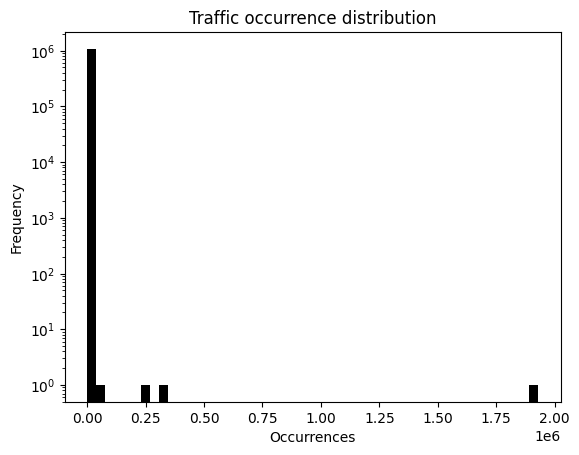

In [8]:
plt.title('Traffic occurrence distribution')
plt.hist(kdd_df['occurrences'], bins=50, color='black')
plt.xlabel('Occurrences')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

### 2.3. Feature definitions

In [9]:
# Define string, int and float features
string_features = [
    'protocol_type', 'service', 'flag'
]

int_features = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'dst_host_count',
    'dst_host_srv_count',
    'occurrences',
]

float_features =[
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate'
]


In [10]:
# Clean binary encoded features
kdd_df[string_features] = kdd_df[string_features].astype('string')

# Set feature data types
kdd_df[string_features] = kdd_df[string_features].astype('category')
kdd_df[int_features] = kdd_df[int_features].astype('int')
kdd_df[float_features] = kdd_df[float_features].astype('float')

kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Data columns (total 42 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   duration                     1074992 non-null  int64   
 1   protocol_type                1074992 non-null  category
 2   service                      1074992 non-null  category
 3   flag                         1074992 non-null  category
 4   src_bytes                    1074992 non-null  int64   
 5   dst_bytes                    1074992 non-null  int64   
 6   land                         1074992 non-null  int64   
 7   wrong_fragment               1074992 non-null  int64   
 8   urgent                       1074992 non-null  int64   
 9   hot                          1074992 non-null  int64   
 10  num_failed_logins            1074992 non-null  int64   
 11  logged_in                    1074992 non-null  int64   
 12  num_compromised              1074992 no

In [11]:
kdd_df.head().T

,0,1,2,3,4
duration,0,0,0,0,0
protocol_type,tcp,tcp,tcp,tcp,tcp
service,http,http,http,http,http
flag,SF,SF,SF,SF,SF
src_bytes,215,162,236,233,239
dst_bytes,45076,4528,1228,2032,486
land,0,0,0,0,0
wrong_fragment,0,0,0,0,0
urgent,0,0,0,0,0
hot,0,0,0,0,0


## 3. EDA & pre-processing

### 3.1. String (categorical) features

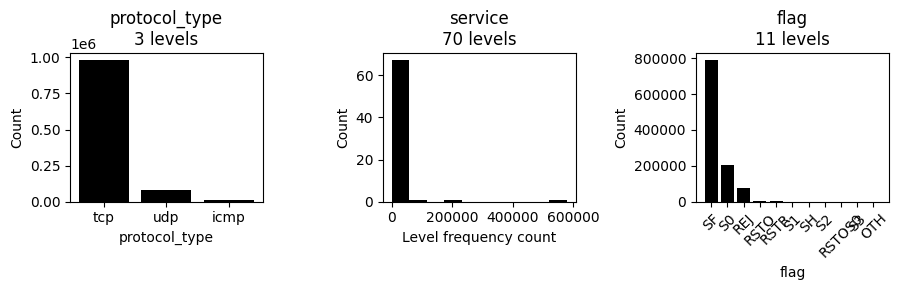

In [12]:
import math

fig, axes = plt.subplots(
    math.ceil(len(string_features) / 3),
    3,
    figsize=(9, math.ceil(len(string_features) / 3) * 3)
)

axes = axes.flatten()

for i, feature in enumerate(string_features):

    counts = kdd_df[feature].value_counts()

    axes[i].set_title(f'{feature}\n{len(counts)} levels')

    if len(counts) > 20:
        axes[i].hist(counts.values, bins=10, color='black')
        axes[i].set_xlabel('Level frequency count')
        axes[i].set_ylabel('Count')

    else:
        axes[i].bar(counts.index.astype(str), counts.values, color='black')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')

        if len(counts) > 10:
            axes[i].tick_params(axis='x', rotation=45)

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

Thinking we should use try one-hot here - we are going to end up with > 80 features, but we can just SVD them later if needed. This approach preserves the information content better than hashing and does not impose arbitrary order like ordinal encoding.

In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = encoder.fit_transform(kdd_df[string_features])

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out()
)

kdd_df = pd.concat([kdd_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
kdd_df.drop(string_features, axis=1, inplace=True)

### 3.2. Integer (count) features

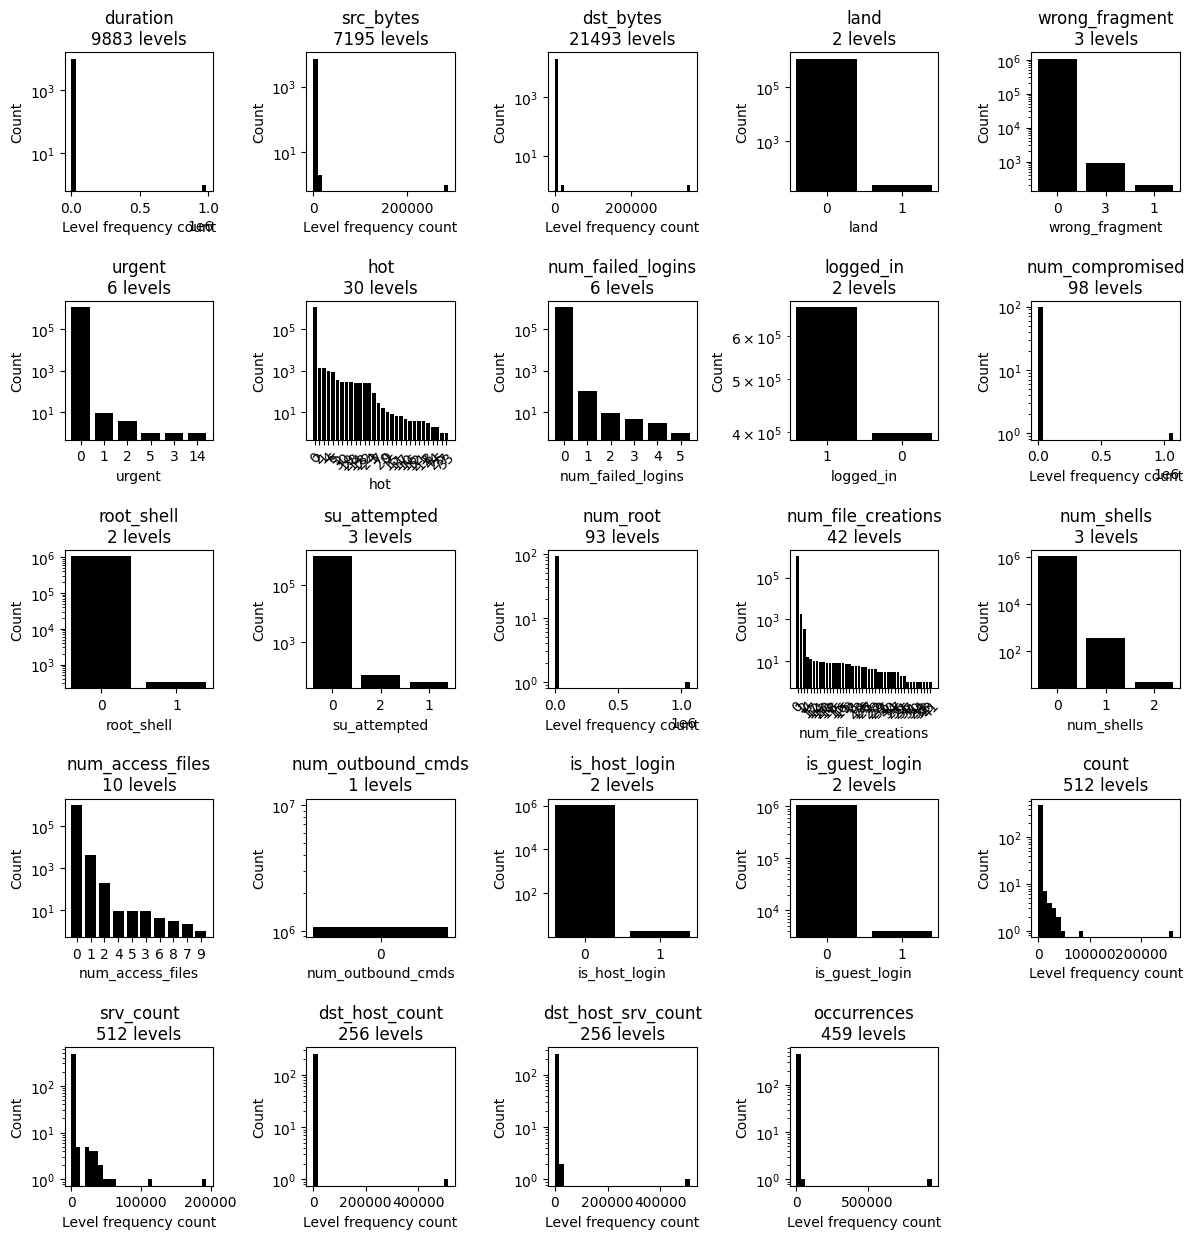

In [14]:
fig, axes = plt.subplots(
    math.ceil(len(int_features) / 5),
    5,
    figsize=(12, math.ceil(len(int_features) / 5) * 2.5)
)

axes = axes.flatten()

for i, feature in enumerate(int_features):

    counts = kdd_df[feature].value_counts()

    axes[i].set_title(f'{feature}\n{len(counts)} levels')

    if len(counts) > 50:
        bins = max(30, len(counts) // 500)
        axes[i].hist(counts.values, bins=bins, color='black')
        axes[i].set_xlabel('Level frequency count')
        axes[i].set_ylabel('Count')

    else:
        axes[i].bar(counts.index.astype(str), counts.values, color='black')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Count')

        if len(counts) > 10:
            axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_yscale('log')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

OK - a few things jump out right away:

1. The integer features are a mix of high and low cardnality. Some are binary, while at the other extreme some have thousands of levels.
2. Most low cardnality features are dominated by one category (see `land` or `wrong_fragment`), while high cardnality features often have many levels that show up only a few times, and some that show up many times (see `duration` or `src_bytes`).
3. `num_outbound_cmds` is constant and can be dropped.

Let's break the integer features into finer categories so we can handle the cases differently.

1. **Binary** (ex: `land`, `logged_in`): leave as 0/1 encoding and cast to bool.
2. **Low cardnality count** (ex: `num_failed_logins`): leave as ordinal encoding.
3. **Skewed high cardnality count** (ex: `src_bytes`): treat as continuous, power tranform.

In [15]:
# Drop constant feature
kdd_df.drop('num_outbound_cmds', axis=1, inplace=True)
int_features.remove('num_outbound_cmds')

In [16]:
# New feature subset definitions for integer features
binary_features = []
low_cardinality = []
high_cardinality = []

for feature in int_features:
    if kdd_df[feature].nunique() == 2:
        binary_features.append(feature)

    elif kdd_df[feature].nunique() < 50:
        low_cardinality.append(feature)

    elif kdd_df[feature].nunique() >= 50:
        high_cardinality.append(feature)

    else:
        print(f"Don't know what to do with {feature}")

print(f'Binary features: {", ".join(binary_features)}\n')
print(f'Low cardinality features: {", ".join(low_cardinality)}\n')
print(f'High cardinality features: {", ".join(high_cardinality)}\n')
print(f'Total integer features: {len(binary_features + low_cardinality + high_cardinality)}')

Binary features: land, logged_in, root_shell, is_host_login, is_guest_login

Low cardinality features: wrong_fragment, urgent, hot, num_failed_logins, su_attempted, num_file_creations, num_shells, num_access_files

High cardinality features: duration, src_bytes, dst_bytes, num_compromised, num_root, count, srv_count, dst_host_count, dst_host_srv_count, occurrences

Total integer features: 23


In [17]:
# Set type for binary features
kdd_df[binary_features] = kdd_df[binary_features].astype('bool')

In [18]:
from sklearn.preprocessing import PowerTransformer

# Power transform the high cardinality features
transformer = PowerTransformer(method='yeo-johnson', standardize=True)
kdd_df[high_cardinality] = transformer.fit_transform(kdd_df[high_cardinality])

In [19]:
# Result
kdd_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074992 entries, 0 to 1074991
Columns: 122 entries, duration to flag_SH
dtypes: bool(5), float64(109), int64(8)
memory usage: 964.7 MB


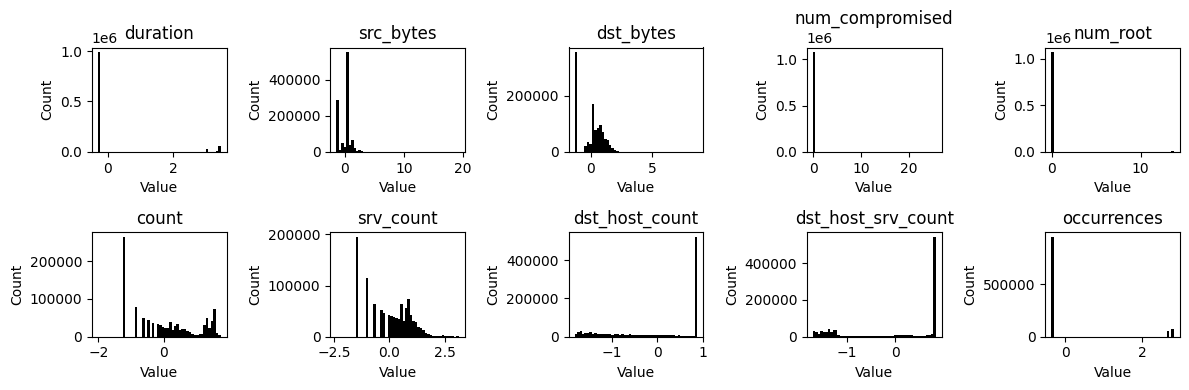

In [25]:
fig, axes = plt.subplots(
    math.ceil(len(high_cardinality) / 5),
    5,
    figsize=(12, math.ceil(len(high_cardinality) / 5) * 2)
)

axes = axes.flatten()

for i, feature in enumerate(high_cardinality):

    axes[i].set_title(feature)

    axes[i].hist(kdd_df[feature], bins=50, color='black')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()

##### 3.7.1.3. Continuous features
OK, now let's look at the distribution of the continuous features.

In [ ]:
continuous_features = [
    'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent',
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'count', 'srv_count', 
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

In [ ]:
n_cols = 5

fig, axes = plt.subplots(
    math.ceil(len(continuous_features) / n_cols),
    n_cols,
    figsize=(12, math.ceil(len(continuous_features) / n_cols) * 2.25)
)

axes = axes.flatten()

for i, feature in enumerate(continuous_features):

    counts = kdd_df[feature].value_counts()

    axes[i].set_title(f'{feature}\n{len(counts)} unique values')

    axes[i].hist(kdd_df[feature], bins=50, color='black')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

while i < len(axes) - 1:
    axes[i + 1].set_visible(False)
    i += 1

plt.tight_layout()
plt.show()

OK - I had a hunch... many of the continuous features have very low cardinality and could be treated as categorical. Others are very skewed or have extreme outliers. Let's take a closer look at just cardinality.

In [ ]:
kdd_df[continuous_features].nunique().sort_values(ascending=False)

In [ ]:
# num_outbound_cmds and logged_in are both constant and can be dropped
kdd_df.drop(columns=['num_outbound_cmds', 'logged_in'], inplace=True)  

I think that's it for now - we could ordinal or one-hot encode some of the remaining low cardinality continuous features, and scale or transform the others. But, since we are going to use a tree based approach the scale doesn't matter, and for count features, I'd rather have holes where no-one had that count, rather than ordinally encoding them. So, I think we can leave the continuous features as-is for now.

#### 3.7.2. Isolation forest

In [ ]:
contamination = 0.01

iso_forest = IsolationForest(contamination=contamination, random_state=315)
iso_forest_labels = iso_forest.fit_predict(kdd_df)

n_outliers = (iso_forest_labels == -1).sum()
print(f'Isolation Forest: {n_outliers} anomalies detected ({n_outliers / len(iso_forest_labels):.1%})')

#### 3.7.3. Results visualization

In [ ]:
# Standard scale for PCA projection
scaler = StandardScaler()
scaled_kdd_df = pd.DataFrame(scaler.fit_transform(kdd_df), columns=kdd_df.columns)

# Project to 3D for visualization
pca_vis = PCA(n_components=3, random_state=315)
kdd_vis_df = pd.DataFrame(pca_vis.fit_transform(scaled_kdd_df), columns=['PC1', 'PC2', 'PC3'])

# Convert sklearn's -1/1 output to 0/1
def to_binary(labels):
    return (np.array(labels) == -1).astype(int)

kdd_vis_df['Anomaly'] = to_binary(iso_forest_labels)

In [ ]:
import plotly.express as px

# Standard scale for PCA projection

fig = px.scatter_3d(
    kdd_vis_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Anomaly',
    title='Anomaly distribution in 3D'
)

fig.update_traces(marker=dict(size=2))
fig.show()